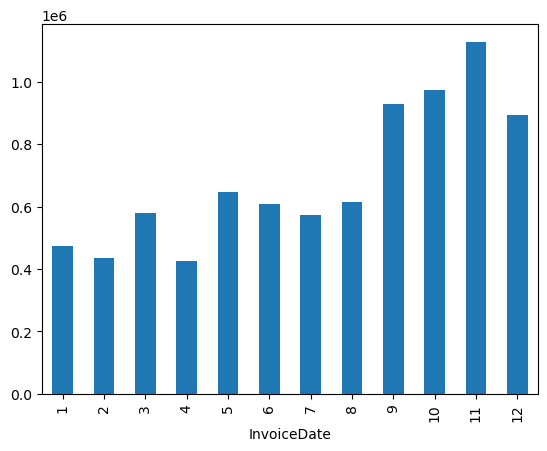

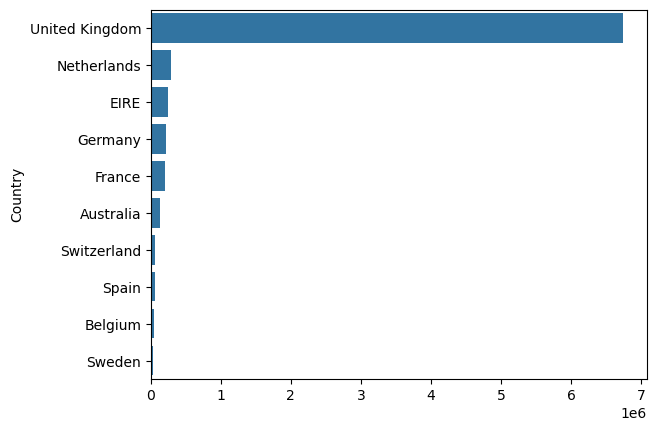

In [33]:
# Load Data
import pandas as pd

df = pd.read_excel("online_retail_cleaned.csv.xlsx")

df.head()

# Data Cleaning
df.drop_duplicates(inplace=True)

df.dropna(inplace=True)

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Descriptive Statistics
df.describe()

### Correlation
df.corr(numeric_only=True)

### Monthly Sales
import matplotlib.pyplot as plt

monthly_sales = df.groupby(df['InvoiceDate'].dt.month)['TotalPrice'].sum()

monthly_sales.plot(kind='bar')

plt.show()

### Country Revenue
import seaborn as sns

country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

sns.barplot(
    x=country_sales.values,
    y=country_sales.index
)
# Create customer summary
customer_df = df.groupby('CustomerID').agg({
    'InvoiceNo':'count',
    'TotalPrice':'sum'
})

customer_df.columns = ['Frequency','Monetary']

## K-Means Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

customer_df['Cluster'] = kmeans.fit_predict(customer_df)

top_products = (
    df.groupby('Description')
      ['Quantity']
      .sum()
      .sort_values(ascending=False)
)